<a href="https://colab.research.google.com/github/Naman1232/ML-PROJECTS/blob/main/Denoising_in_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import mnist

MNIST consists of 70,000 images of handwritten digits (0-9) and is mainly used to train and test deep learning models for image classification

In [2]:
from tensorflow.keras.layers import Input,Dense,Conv2D,MaxPooling2D,UpSampling2D,Cropping2D
from tensorflow.keras.models import Sequential

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
(x_train, _),(x_test, _)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [6]:
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [7]:
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

 1. **`noise_factor = 0.5`** → Sets how much noise to add.  
2. **`np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)`** → Creates random noise with a mean of **0** and standard deviation of **1** in the same shape as `x_train`.  
3. **`x_train_noisy = x_train + noise_factor * (random noise)`** → Adds noise to training images.  
4. **`x_test_noisy = x_test + noise_factor * (random noise)`** → Adds noise to test images.  

🔹 **Purpose:** Simulates noisy images to train models for denoising tasks. 🚀

In [8]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

When noise is added, some pixel values might go below 0 or above 1. Clipping keeps them within the valid range for image processing

Clipping helps in making the image look visually better by:

Preventing overly bright (values >1) or too dark (values <0) pixels.
Maintaining proper contrast and structure of the image.
Ensuring the image remains within a valid range for display and processing.

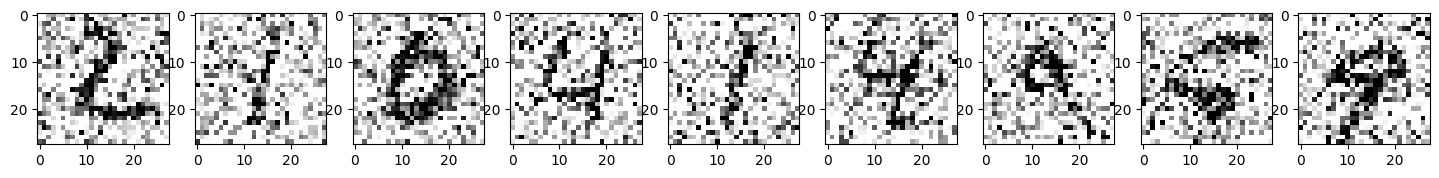

In [9]:
plt.figure(figsize=(20, 2))
for i in range(1,10):
    ax = plt.subplot(1, 10, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="binary")
plt.show()

In [10]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.add(MaxPooling2D((2, 2), padding='same'))

In [12]:
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(1, (3, 3), activation='relu', padding='same'))

In [13]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 8)           │           2,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 4, 4, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 8, 8, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 16, 16, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 14, 14, 32)          │           2,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_2 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,009 (27.38 KB)

 Trainable params: 7,009 (27.38 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.fit(x_train_noisy, x_train, epochs=10, batch_size=256, shuffle=True,
          validation_data=(x_test_noisy, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 111s 456ms/step - loss: 0.0652 - val_loss: 0.0401
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 129s 405ms/step - loss: 0.0384 - val_loss: 0.0345
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 413ms/step - loss: 0.0330 - val_loss: 0.0301
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 98s 417ms/step - loss: 0.0299 - val_loss: 0.0281
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 99s 423ms/step - loss: 0.0281 - val_loss: 0.0271
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 140s 415ms/step - loss: 0.0268 - val_loss: 0.0263
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 141s 413ms/step - loss: 0.0259 - val_loss: 0.0251
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 98s 417ms/step - loss: 0.0252 - val_loss: 0.0245
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 421ms/step - loss: 0.0246 - val_loss: 0.0241
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 97s 412ms/step - loss: 0.0241 - val_loss: 0.0236


In [16]:
model.evaluate(x_test_noisy, x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0237


0.023562123998999596

In [17]:
no_noise_img = model.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


`no_noise_img = model.predict(x_test_noisy)` means:  

- The model takes **noisy images** (`x_test_noisy`) as input.  
- It tries to **predict** the cleaned (denoised) version of the images.  
- The output (`no_noise_img`) contains the **denoised images** generated by the model.

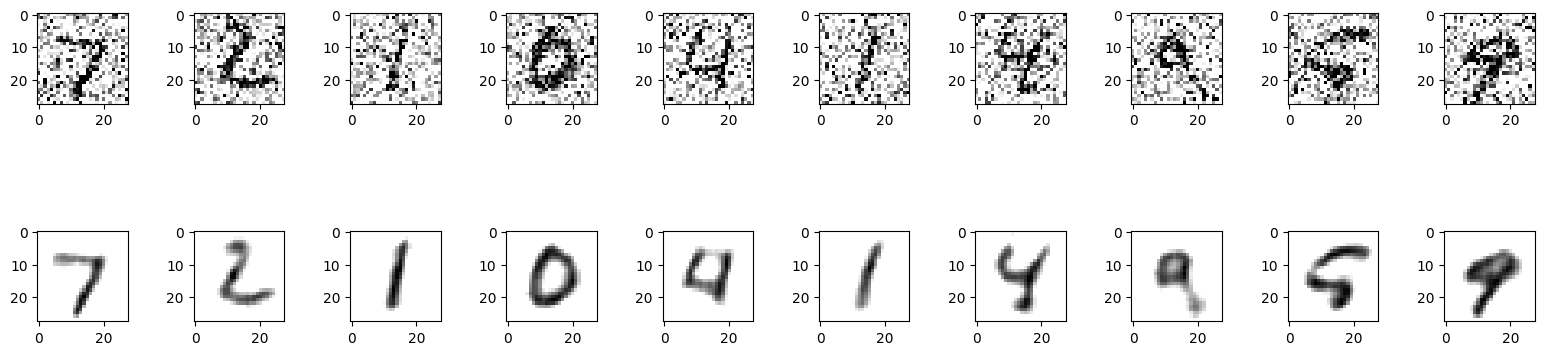

In [18]:
plt.figure(figsize=(40, 4))
for i in range(10):

    ax = plt.subplot(3, 20, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="binary")

    ax = plt.subplot(3, 20, 40 +i+ 1)
    plt.imshow(no_noise_img[i].reshape(28, 28), cmap="binary")

In [19]:
plt.show()


1. **Create a large figure** (`40x4` size) for displaying images.  
2. **Loop through 10 images** (`for i in range(10)`).  
3. **Plot the noisy images**:  
   - Use `plt.imshow(x_test_noisy[i].reshape(28,28), cmap="binary")` to display the noisy version.  
   - Place it in the **first row** (`subplot(3,20,i+1)`).  
4. **Plot the denoised images**:  
   - Use `plt.imshow(no_noise_img[i].reshape(28,28), cmap="binary")` to display the cleaned version.  
   - Place it in the **third row** (`subplot(3,20,40+i+1)`).  
5. **Show the final visualization** using `plt.show()`.  

This helps compare the **input (noisy images) vs. output (denoised images)**.